# Publication Figures from pySCENIC Results

This notebook generates three figures from your pySCENIC regulon analysis:

1. **Regulon activity heatmap** for 4 epithelial cell populations, with Gata3, Foxa1, and Pgr highlighted.
2. **Regulon dot plot** of TF gene expression for 15 selected TFs, split by WT/KO condition.
3. **Violin plots** of TF gene expression across populations, split by condition.


In [1]:
import numpy as np
import os
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.sparse import issparse
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams["figure.dpi"] = 150

## Configuration

- **`H5AD_PATH`**: Points to `adata_with_aucell.h5ad`, which contains both the expression matrix in `adata.X` and AUCell scores in `adata.obsm['X_aucell']`.
- **`AUC_CSV_PATH`**: Set to `None` since AUCell scores are already embedded in the h5ad file.

> **Important:** Figures 2 & 3 pull raw gene expression from `adata.X` for the 15 TF genes. If `adata_with_aucell.h5ad` was built from the pre-filtered expression matrix (restricted to DB-present genes for GRNBoost2), some TFs may be missing from `.var_names`. A verification cell below checks this. If genes are missing, use your **original unfiltered h5ad** for `H5AD_PATH` and point `AUC_CSV_PATH` to the AUCell output CSV instead.

In [2]:
H5AD_PATH       = "output_filtered_epi/adata_with_aucell.h5ad"
TVALUES_CSV_PATH = "regulon_heatmap_filtered_epi/regulon_tvalues_per_celltype.csv"
AUC_CSV_PATH    = None 
REGULONS_PKL    = "output_filtered_epi/regulons.pkl"  # regulons pickle for target gene counts

# If TF genes are missing from adata.X (see verification cell below),
# uncomment the following two lines and point to your original unfiltered
# h5ad + the AUCell CSV:
# H5AD_PATH     = "/path/to/original_unfiltered.h5ad"
# AUC_CSV_PATH  = "/path/to/aucell.csv"

CELL_TYPE_COL   = "cluster_annot"             # column in adata.obs
CONDITION_COL   = "condition"             # column in adata.obs (WT/KO)
N_TOP           = 5                       # top regulons per population for heatmap
OUTPUT_DIR      = "publication_figures"

# ============================================================================
# Cell populations (ordered as desired on the heatmap y-axis)
# ============================================================================
CELL_POPULATIONS = [
    "Epi_Ctr9+",
    "Epi_Kit+Elf5+",
    "Epi_proliferating",
    "BasalEpi_Acta2+Trp63",
]

# TFs to highlight in the heatmap (bold red labels)
HIGHLIGHT_TFS = ["Gata3", "Foxa1", "Pgr"]

# TFs for the dot plot and violin plots
DOTPLOT_TFS = [
    "Gata3", "Tfap2b", "Foxa1", "Pgr",
    "E2f1", "E2f2", "E2f3",
    "Etv1", "Zeb1", "Pitx1", "Tead1",
    "Elf5", "Klf4", "Bcl11a", "Sox10",
]

## Helper Functions


In [3]:
def regulon_to_tf(regulon_name):
    """Extract TF gene name from regulon name, e.g. 'Stat5a(+)' -> 'Stat5a'."""
    name = str(regulon_name)
    for suffix in ["(+)", "(-)", "(~)"]:
        if name.endswith(suffix):
            name = name[: -len(suffix)]
            break
    return name.strip()


def find_gene_in_adata(gene, adata):
    """Case-insensitive gene lookup in adata.var_names."""
    if gene in adata.var_names:
        return gene
    matches = [g for g in adata.var_names if g.lower() == gene.lower()]
    return matches[0] if matches else None


def find_regulon_in_auc(tf_name, auc_columns):
    """Try to match a TF to a regulon column (case-insensitive, tries (+) and (-))."""
    candidate = f"{tf_name}(+)"
    if candidate in auc_columns:
        return candidate
    for col in auc_columns:
        if col.lower() == candidate.lower():
            return col
    candidate_neg = f"{tf_name}(-)"
    for col in auc_columns:
        if col.lower() == candidate_neg.lower():
            return col
    return None

## Load Data


In [4]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Loading AnnData from: {H5AD_PATH}")
adata = sc.read_h5ad(H5AD_PATH)
print(f"  Shape: {adata.shape[0]} cells x {adata.shape[1]} genes")

if AUC_CSV_PATH is not None:
    print(f"Loading AUCell matrix from: {AUC_CSV_PATH}")
    auc_df = pd.read_csv(AUC_CSV_PATH, index_col=0)
elif "X_aucell" in adata.obsm and "aucell_regulon_names" in adata.uns:
    print("Using AUCell scores from adata.obsm['X_aucell']")
    auc_df = pd.DataFrame(
        adata.obsm["X_aucell"],
        index=adata.obs_names,
        columns=adata.uns["aucell_regulon_names"],
    )
else:
    raise ValueError("No AUCell data found. Set AUC_CSV_PATH or ensure adata has obsm['X_aucell'].")

print(f"  AUCell shape: {auc_df.shape}")

# Align cells
common = auc_df.index.intersection(adata.obs_names)
print(f"  Common cells: {len(common)}")
adata = adata[common].copy()
auc_df = auc_df.loc[common]

# Extract metadata
cell_types = adata.obs[CELL_TYPE_COL].astype(str)
conditions = adata.obs[CONDITION_COL].astype(str)

print(f"\nCell types ({cell_types.nunique()}):")
print(cell_types.value_counts().to_string())
print(f"\nConditions:")
print(conditions.value_counts().to_string())

# Drop zero-variance regulons
auc_df = auc_df.loc[:, auc_df.var() > 0]
print(f"\nRegulons after dropping zero-variance: {auc_df.shape[1]}")

# Check requested populations
available = set(cell_types.unique())
for pop in CELL_POPULATIONS:
    status = "OK" if pop in available else "NOT FOUND"
    print(f"  {pop}: {status}")

# Load regulon target-gene counts from pickle
import pickle
regulon_gene_counts = {}
if REGULONS_PKL is not None and os.path.exists(REGULONS_PKL):
    with open(REGULONS_PKL, "rb") as f:
        regulons_list = pickle.load(f)
    regulon_gene_counts = {r.name: len(r.genes) for r in regulons_list}
    print(f"\nLoaded target-gene counts for {len(regulon_gene_counts)} regulons from pickle")
    print(f"  Example: {list(regulon_gene_counts.items())[:3]}")
else:
    print(f"\nWARNING: regulons pickle not found at '{REGULONS_PKL}'. "
          "Heatmap labels will keep (+) suffix.")


Loading AnnData from: output_filtered_epi/adata_with_aucell.h5ad
  Shape: 4041 cells x 33696 genes
Using AUCell scores from adata.obsm['X_aucell']
  AUCell shape: (4041, 455)
  Common cells: 4041

Cell types (4):
cluster_annot
Epi_Kit+Elf5+           1811
BasalEpi_Acta2+Trp63    1066
Epi_Ctr9+                943
Epi_proliferating        221

Conditions:
condition
WT_DM    2165
KO_DM    1876

Regulons after dropping zero-variance: 455
  Epi_Ctr9+: OK
  Epi_Kit+Elf5+: OK
  Epi_proliferating: OK
  BasalEpi_Acta2+Trp63: OK

Loaded target-gene counts for 455 regulons from pickle
  Example: [('Aebp2(+)', 11), ('Ahr(+)', 5), ('Alx4(+)', 59)]


### Verify TF Genes in adata.X

Figures 2 & 3 need raw gene expression from `adata.X` for all 15 TF genes.
If any are missing (because `adata_with_aucell.h5ad` was built from a
gene-filtered matrix), you'll need to switch to your original unfiltered
h5ad.


In [5]:
print("Checking TF gene availability in adata.var_names:")
print(f"  Total genes in adata: {adata.n_vars}\n")

all_found = True
for tf in DOTPLOT_TFS:
    matched = find_gene_in_adata(tf, adata)
    if matched:
        print(f"  {tf:12s} -> {matched:12s}  OK")
    else:
        print(f"  {tf:12s} -> {'—':12s}  MISSING")
        all_found = False

if all_found:
    print("\nAll TF genes found. You're good to proceed with adata_with_aucell.h5ad.")
else:
    print("\n*** Some TF genes are MISSING from adata.X. ***")
    print("This likely means the h5ad was built from a gene-filtered matrix.")
    print("Go back to the Configuration cell and switch to your original")
    print("unfiltered h5ad + the AUCell CSV, then re-run from the Load Data cell.")

Checking TF gene availability in adata.var_names:
  Total genes in adata: 33696

  Gata3        -> Gata3         OK
  Tfap2b       -> Tfap2b        OK
  Foxa1        -> Foxa1         OK
  Pgr          -> Pgr           OK
  E2f1         -> E2f1          OK
  E2f2         -> E2f2          OK
  E2f3         -> E2f3          OK
  Etv1         -> Etv1          OK
  Zeb1         -> Zeb1          OK
  Pitx1        -> Pitx1         OK
  Tead1        -> Tead1         OK
  Elf5         -> Elf5          OK
  Klf4         -> Klf4          OK
  Bcl11a       -> Bcl11a        OK
  Sox10        -> Sox10         OK

All TF genes found. You're good to proceed with adata_with_aucell.h5ad.


---
## Figure 1: Regulon Activity Heatmap

For each regulon, we fit `AUCell ~ is_celltype + condition` (one-vs-rest) and extract the t-value for the cell-type coefficient. Top N regulons per population are selected; Gata3, Foxa1, and Pgr are force-included and highlighted in red.


In [6]:
# Load pre-computed t-values from the regulon heatmap script
tvalue_matrix = pd.read_csv(TVALUES_CSV_PATH, index_col=0)

# Reorder columns to match CELL_POPULATIONS ordering
missing_pops = [p for p in CELL_POPULATIONS if p not in tvalue_matrix.columns]
if missing_pops:
    print(f"WARNING: populations not found in t-values CSV: {missing_pops}")
tvalue_matrix = tvalue_matrix[[p for p in CELL_POPULATIONS if p in tvalue_matrix.columns]]

print(f"Loaded t-value matrix: {tvalue_matrix.shape[0]} regulons x {tvalue_matrix.shape[1]} populations")
print(f"  Source: {TVALUES_CSV_PATH}")

# Save a copy to the output directory for reference
tvalue_matrix.to_csv(os.path.join(OUTPUT_DIR, "fig1_tvalues.csv"))
print(f"  Copied to: {OUTPUT_DIR}/fig1_tvalues.csv")


Loaded t-value matrix: 455 regulons x 4 populations
  Source: regulon_heatmap_filtered_epi/regulon_tvalues_per_celltype.csv
  Copied to: publication_figures/fig1_tvalues.csv


Total regulons to plot: 20


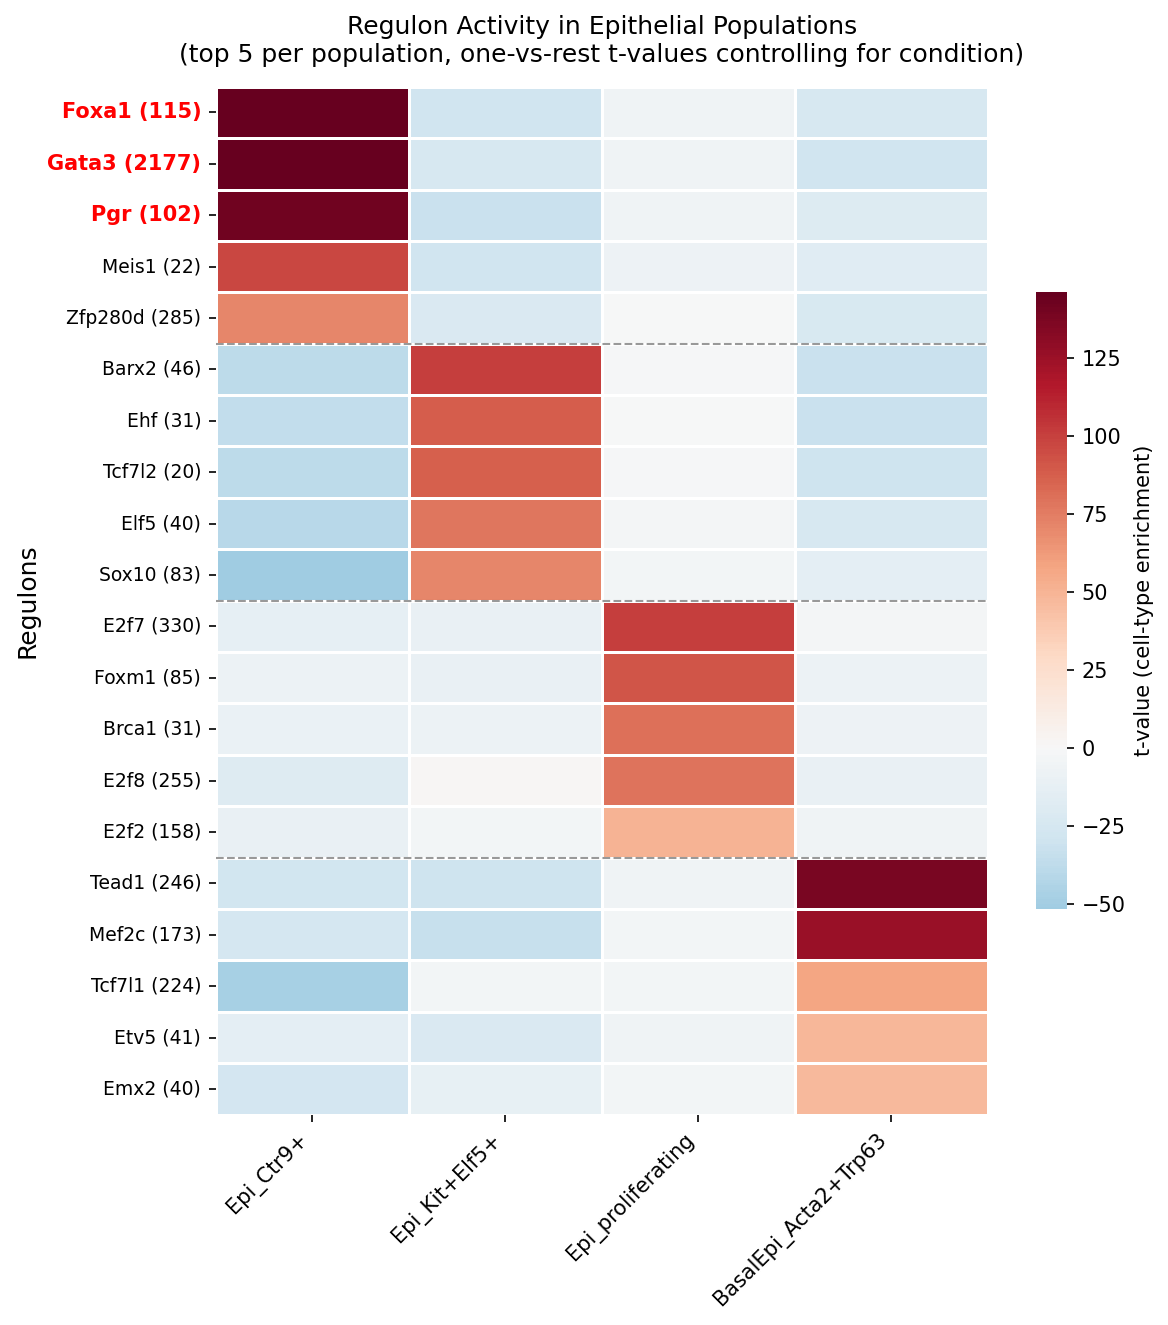

Figure 1 saved.


In [7]:
# Select top regulons per population
selected = []
for ct in tvalue_matrix.columns:
    top = tvalue_matrix[ct].nlargest(N_TOP).index.tolist()
    selected.extend(top)
seen = set()
selected = [r for r in selected if not (r in seen or seen.add(r))]

# Force-include highlighted TFs
for tf in HIGHLIGHT_TFS:
    reg = find_regulon_in_auc(tf, auc_df.columns)
    if reg and reg not in selected:
        selected.append(reg)
        print(f"Added highlighted regulon: {reg}")

print(f"Total regulons to plot: {len(selected)}")

# Sort regulons by which population they are most enriched in
max_pop = tvalue_matrix.loc[selected].idxmax(axis=1)
sorted_regulons = []
for ct in tvalue_matrix.columns:
    regs = max_pop[max_pop == ct].index.tolist()
    regs = sorted(regs, key=lambda r: tvalue_matrix.loc[r, ct], reverse=True)
    sorted_regulons.extend(regs)

plot_df = tvalue_matrix.loc[sorted_regulons]  # regulons x populations

# --- Plot ---
fig_width = max(5, len(plot_df.columns) * 1.2 + 3.5)
fig_height = max(6, len(sorted_regulons) * 0.32 + 2.5)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
sns.heatmap(
    plot_df, cmap="RdBu_r", center=0,
    linewidths=0.5, linecolor="white",
    xticklabels=True, yticklabels=True,
    cbar_kws={"label": "t-value (cell-type enrichment)", "shrink": 0.6},
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("Regulons", fontsize=12)
ax.tick_params(axis="x", rotation=45, labelsize=10)
ax.tick_params(axis="y", rotation=0, labelsize=9)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")
ax.set_title(
    f"Regulon Activity in Epithelial Populations\n"
    f"(top {N_TOP} per population, one-vs-rest t-values controlling for condition)",
    fontsize=12, pad=12,
)

# Relabel y-axis: replace (+) with (N target genes) if counts available
highlight_lower = {tf.lower() for tf in HIGHLIGHT_TFS}
ylabels = ax.get_yticklabels()
for label in ylabels:
    reg_name = label.get_text()
    tf_name = regulon_to_tf(reg_name)
    # Build new label with target gene count
    if reg_name in regulon_gene_counts:
        new_text = f"{tf_name} ({regulon_gene_counts[reg_name]})"
    else:
        new_text = reg_name  # fallback to original
    label.set_text(new_text)
    # Highlight Gata3, Foxa1, Pgr in bold red
    if tf_name.lower() in highlight_lower:
        label.set_color("red")
        label.set_fontweight("bold")
        label.set_fontsize(10)
ax.set_yticklabels(ylabels)

# Horizontal separators between regulon blocks
cursor = 0
for ct in tvalue_matrix.columns:
    n_regs = (max_pop == ct).sum()
    cursor += n_regs
    if cursor < len(sorted_regulons):
        ax.axhline(y=cursor, color="black", linewidth=1.0, linestyle="--", alpha=0.4)

fig.savefig(os.path.join(OUTPUT_DIR, "fig1_regulon_heatmap_epithelial.png")),
fig.savefig(os.path.join(OUTPUT_DIR, "fig1_regulon_heatmap_epithelial.pdf"),
            dpi=300, bbox_inches="tight")
plt.show()
print("Figure 1 saved.")

---
## Figure 2: Regulon Dot Plot of TF Expression

Dot size = fraction of cells expressing the TF gene (> 0).
Dot color = mean expression in expressing cells.
Rows = population × condition, columns = TFs.

**No model / t-values here** — this is purely descriptive from `adata.X`.

Dotplot: 15/15 TFs found


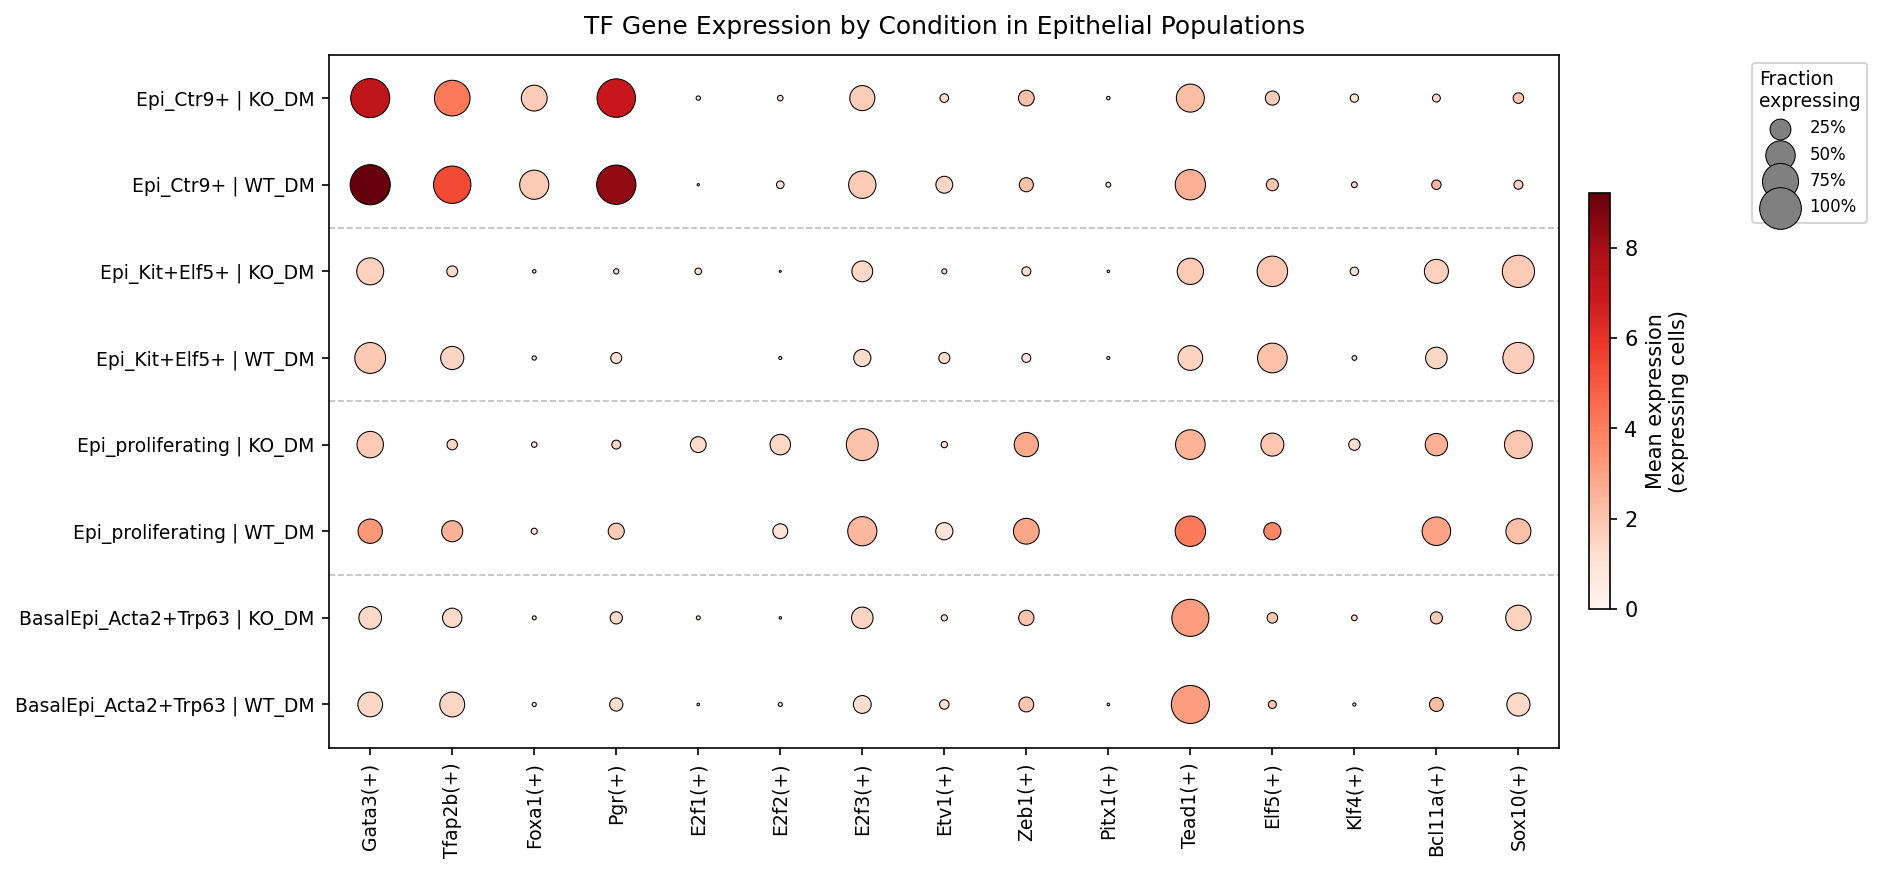

Figure 2 saved.


In [8]:
# Subset to relevant populations
mask = cell_types.isin(CELL_POPULATIONS).values
adata_sub = adata[mask].copy()
ct_sub = cell_types[mask]
cond_sub = conditions[mask]

# Match TFs to genes in adata
gene_map = {}
for tf in DOTPLOT_TFS:
    matched = find_gene_in_adata(tf, adata_sub)
    if matched:
        gene_map[tf] = matched
    else:
        print(f"WARNING: TF gene '{tf}' not found in adata.var_names")

found_tfs = list(gene_map.keys())
found_genes = [gene_map[tf] for tf in found_tfs]
regulon_labels = [f"{tf}(+)" for tf in found_tfs]
n_tfs = len(found_tfs)
print(f"Dotplot: {n_tfs}/{len(DOTPLOT_TFS)} TFs found")

# Get expression matrix
adata_genes = adata_sub[:, found_genes].copy()
X_expr = adata_genes.X
if issparse(X_expr):
    X_expr = X_expr.toarray()

# Group labels
group_labels = ct_sub.astype(str) + " | " + cond_sub.astype(str)
unique_conds = sorted(cond_sub.unique())
row_order = []
for pop in CELL_POPULATIONS:
    for cond in unique_conds:
        label = f"{pop} | {cond}"
        if label in group_labels.values:
            row_order.append(label)

# Compute stats per group
records = []
for grp in row_order:
    grp_mask = (group_labels == grp).values
    X_grp = X_expr[grp_mask]
    for j, tf in enumerate(found_tfs):
        vals = X_grp[:, j]
        frac = (vals > 0).mean()
        mean_expr = vals[vals > 0].mean() if (vals > 0).any() else 0.0
        records.append({"group": grp, "tf": tf, "regulon": regulon_labels[j],
                        "frac_expressing": frac, "mean_expression": mean_expr})

df_dot = pd.DataFrame(records)

# --- Plot ---
fig_width = max(9, n_tfs * 0.65 + 3)
fig_height = max(4, len(row_order) * 0.5 + 2)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

y_map = {grp: i for i, grp in enumerate(reversed(row_order))}
x_map = {tf: i for i, tf in enumerate(found_tfs)}
vmax = df_dot["mean_expression"].max()

sx, sy, ss, sc_vals = [], [], [], []
for _, row in df_dot.iterrows():
    sx.append(x_map[row["tf"]])
    sy.append(y_map[row["group"]])
    ss.append(row["frac_expressing"] * 400)
    sc_vals.append(row["mean_expression"])

sc_obj = ax.scatter(sx, sy, s=ss, c=sc_vals, cmap="Reds",
                     edgecolors="black", linewidths=0.5, vmin=0, vmax=vmax, zorder=3)

ax.set_xticks(range(n_tfs))
ax.set_xticklabels(regulon_labels, rotation=90, fontsize=9)
ax.set_yticks(range(len(row_order)))
ax.set_yticklabels(list(reversed(row_order)), fontsize=9)
ax.set_xlim(-0.5, n_tfs - 0.5)
ax.set_ylim(-0.5, len(row_order) - 0.5)

# Horizontal separators between populations
for i in range(1, len(CELL_POPULATIONS)):
    y_sep = len(unique_conds) * i - 0.5
    ax.axhline(y=y_sep, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

ax.set_title("TF Gene Expression by Condition in Epithelial Populations", fontsize=12, pad=10)
plt.colorbar(sc_obj, ax=ax, label="Mean expression\n(expressing cells)", shrink=0.6, pad=0.02)

# Size legend
for frac in [0.25, 0.50, 0.75, 1.0]:
    ax.scatter([], [], s=frac * 400, c="gray", edgecolors="black",
               linewidths=0.5, label=f"{frac:.0%}")
ax.legend(title="Fraction\nexpressing", loc="upper left",
          bbox_to_anchor=(1.15, 1.0), fontsize=8, title_fontsize=9, framealpha=0.8)

fig.savefig(os.path.join(OUTPUT_DIR, "fig2_regulon_dotplot_tf_expression.png")),
fig.savefig(os.path.join(OUTPUT_DIR, "fig2_regulon_dotplot_tf_expression.pdf"),
            dpi=300, bbox_inches="tight")
plt.show()
print("Figure 2 saved.")


---
## Figure 3: Violin Plots of TF Gene Expression

Per-cell expression distributions from `adata.X`, split by WT/KO condition.
Each row block is a cell population, each panel is one TF.

**No model / t-values here** — raw expression distributions only.


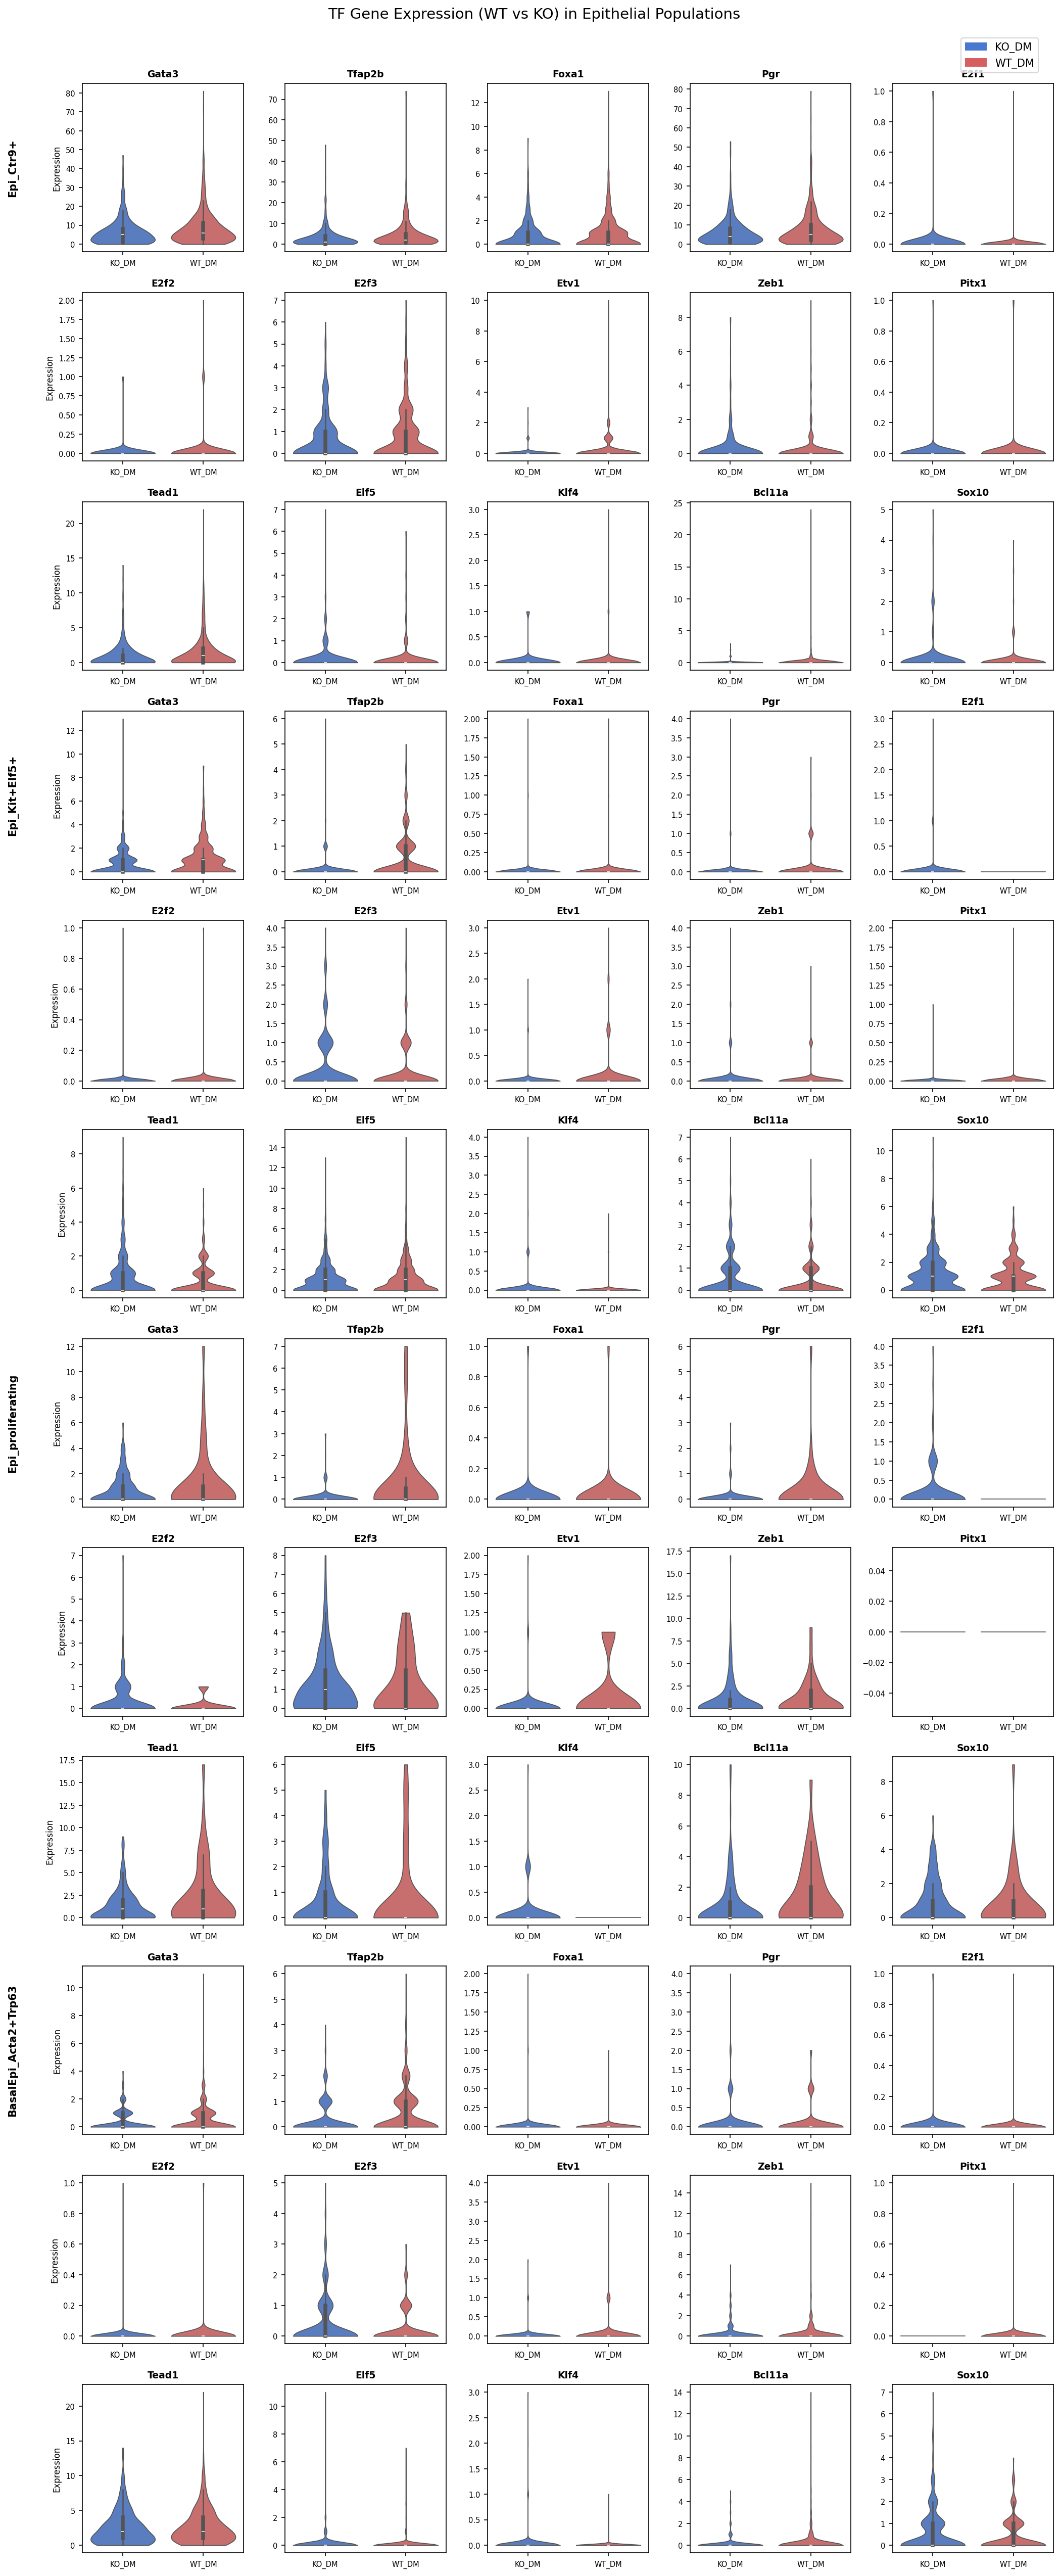

Figure 3 saved.


In [9]:
# Reuse mask, adata_sub, ct_sub, cond_sub, gene_map, found_tfs from above
X_violin = adata_sub[:, found_genes].X
if issparse(X_violin):
    X_violin = X_violin.toarray()

expr_df = pd.DataFrame(X_violin, columns=found_tfs, index=adata_sub.obs_names)
expr_df["cell_type"] = ct_sub.values
expr_df["condition"] = cond_sub.values

unique_conds = sorted(cond_sub.unique())
palette = {unique_conds[0]: "#4878D0", unique_conds[1]: "#D65F5F"}

n_cols = min(5, n_tfs)
n_rows_per_pop = int(np.ceil(n_tfs / n_cols))
total_rows = len(CELL_POPULATIONS) * n_rows_per_pop

fig, axes = plt.subplots(
    total_rows, n_cols,
    figsize=(n_cols * 2.8, total_rows * 2.8),
    squeeze=False,
)

for pop_idx, pop in enumerate(CELL_POPULATIONS):
    pop_data = expr_df[expr_df["cell_type"] == pop]
    if pop_data.empty:
        print(f"WARNING: No cells for '{pop}'")
        continue

    for tf_idx, tf in enumerate(found_tfs):
        row_i = pop_idx * n_rows_per_pop + tf_idx // n_cols
        col_i = tf_idx % n_cols
        ax = axes[row_i][col_i]

        sub = pop_data[[tf, "condition"]].rename(columns={tf: "expression"})
        sns.violinplot(
            data=sub, x="condition", y="expression",
            order=unique_conds, palette=palette,
            inner="box", linewidth=0.8, cut=0, ax=ax,
        )
        ax.set_title(f"{tf}", fontsize=9, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Expression" if col_i == 0 else "", fontsize=8)
        ax.tick_params(labelsize=7)

    # Label the population on the left edge
    first_row = pop_idx * n_rows_per_pop
    axes[first_row][0].annotate(
        pop, xy=(-0.4, 0.5), xycoords="axes fraction",
        fontsize=10, fontweight="bold", rotation=90, va="center", ha="right",
    )

    # Hide unused panels
    for tf_idx in range(n_tfs, n_rows_per_pop * n_cols):
        row_i = pop_idx * n_rows_per_pop + tf_idx // n_cols
        col_i = tf_idx % n_cols
        if row_i < total_rows:
            axes[row_i][col_i].set_visible(False)

fig.suptitle("TF Gene Expression (WT vs KO) in Epithelial Populations",
             fontsize=14, y=1.01)
handles = [mpatches.Patch(color=palette[c], label=c) for c in unique_conds]
fig.legend(handles=handles, loc="upper right", fontsize=10, bbox_to_anchor=(0.98, 1.0))

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "fig3_tf_expression_violins.png")),
fig.savefig(os.path.join(OUTPUT_DIR, "fig3_tf_expression_violins.pdf"),
            dpi=300, bbox_inches="tight")
plt.show()
print("Figure 3 saved.")


---
## Output Summary

All figures are saved to `publication_figures/`:

| File | Description |
|------|-------------|
| `fig1_regulon_heatmap_epithelial.png` | Regulon activity heatmap (4 populations, Gata3/Foxa1/Pgr highlighted) |
| `fig1_tvalues.csv` | Full t-value matrix for the 4 populations |
| `fig2_regulon_dotplot_tf_expression.png` | Dot plot of TF expression by condition |
| `fig3_tf_expression_violins.png` | Violin plots of TF expression by condition |
